# Notebook 13 — Final Project Audit

This notebook performs the final methodological, data-integrity,
reproducibility, and output-consistency audit of the completed
credit-default prediction project.

The notebook does not retrain the model.

The audit verifies:

- Dataset and split sizes
- Predictor dimensions
- Probability alignment
- Probability ranges
- Train/calibration/test separation
- Calibration-set threshold selection
- Frozen final threshold
- Final untouched test-set evaluation
- Confusion-matrix consistency
- Final metric consistency
- Feature-importance outputs
- Risk-group outputs
- Required project artifacts
- Reproducibility of reported results

In [70]:
import os
import json
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("NOTEBOOK 13 - FINAL PROJECT AUDIT")


NOTEBOOK 13 - FINAL PROJECT AUDIT


#### Required variables

In [71]:
import os
import joblib
import numpy as np
import pandas as pd

print("=" * 75)
print("LOADING FINAL MODEL AND FINAL EVALUATION ARTIFACTS")
print("=" * 75)

RANDOM_STATE = 42
SELECTED_THRESHOLD = 0.31

# Exact final artifact directory
ARTIFACT_DIR = os.path.join("outputs", "final_artifacts")

# Load the EXACT model used in Notebook 12
final_base_model = joblib.load(
    os.path.join(ARTIFACT_DIR, "final_base_model.joblib")
)

# Load exact calibration/test data
X_model_train = joblib.load(
    os.path.join(ARTIFACT_DIR, "X_model_train.joblib")
)

y_model_train = joblib.load(
    os.path.join(ARTIFACT_DIR, "y_model_train.joblib")
)

X_calibration = joblib.load(
    os.path.join(ARTIFACT_DIR, "X_calibration.joblib")
)

y_calibration = joblib.load(
    os.path.join(ARTIFACT_DIR, "y_calibration.joblib")
)

X_test = joblib.load(
    os.path.join(ARTIFACT_DIR, "X_test.joblib")
)

y_test = joblib.load(
    os.path.join(ARTIFACT_DIR, "y_test.joblib")
)

# Load probabilities generated by the EXACT final model
train_prob = joblib.load(
    os.path.join(ARTIFACT_DIR, "train_prob.joblib")
)

calibration_prob = joblib.load(
    os.path.join(ARTIFACT_DIR, "calibration_prob.joblib")
)

test_prob = joblib.load(
    os.path.join(ARTIFACT_DIR, "test_prob.joblib")
)

print("✓ Final model loaded")
print("✓ Calibration data loaded")
print("✓ Test data loaded")
print("✓ Final probabilities loaded")

print("\nShapes:")
print("Training:", X_model_train.shape)
print("Calibration:", X_calibration.shape)
print("Test:", X_test.shape)

print("\nSelected threshold:", SELECTED_THRESHOLD)

LOADING FINAL MODEL AND FINAL EVALUATION ARTIFACTS
✓ Final model loaded
✓ Calibration data loaded
✓ Test data loaded
✓ Final probabilities loaded

Shapes:
Training: (19200, 23)
Calibration: (4800, 23)
Test: (6000, 23)

Selected threshold: 0.31


#### Recreate final predictions from scratch

In [72]:
print("=" * 75)
print("REBUILDING FINAL TEST PREDICTIONS")
print("=" * 75)

y_test_array = np.asarray(y_test).astype(int)
test_prob_array = np.asarray(test_prob).astype(float)

y_test_pred = (
    test_prob_array >= float(SELECTED_THRESHOLD)
).astype(int)

assert len(y_test_array) == len(test_prob_array)
assert len(y_test_array) == len(y_test_pred)

assert np.all(np.isfinite(test_prob_array))
assert np.all((test_prob_array >= 0) & (test_prob_array <= 1))

print("✓ Predictions rebuilt successfully.")
print("✓ Threshold:", SELECTED_THRESHOLD)
print("✓ Observations:", len(y_test_array))
print("✓ Probability range:", test_prob_array.min(), "to", test_prob_array.max())

REBUILDING FINAL TEST PREDICTIONS
✓ Predictions rebuilt successfully.
✓ Threshold: 0.31
✓ Observations: 6000
✓ Probability range: 0.08973083519376636 to 0.8572843190262533


#### Final confusion matrix audit

In [73]:
print("=" * 75)
print("CONFUSION MATRIX AUDIT")
print("=" * 75)

tn, fp, fn, tp = confusion_matrix(
    y_test_array,
    y_test_pred,
    labels=[0, 1]
).ravel()

audit_confusion_matrix = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=["Actual Non-Default", "Actual Default"],
    columns=["Predicted Non-Default", "Predicted Default"]
)

display(audit_confusion_matrix)

assert tn + fp + fn + tp == len(y_test_array)

print("✓ Threshold =", SELECTED_THRESHOLD)
print("✓ TN =", tn)
print("✓ FP =", fp)
print("✓ FN =", fn)
print("✓ TP =", tp)
print("✓ Total observations =", tn + fp + fn + tp)
print("✓ Confusion matrix verified.")

CONFUSION MATRIX AUDIT


,Predicted Non-Default,Predicted Default
Actual Non-Default,4159,514
Actual Default,702,625


✓ Threshold = 0.31
✓ TN = 4159
✓ FP = 514
✓ FN = 702
✓ TP = 625
✓ Total observations = 6000
✓ Confusion matrix verified.


#### Final test metrics audit

In [74]:
print("=" * 75)
print("FINAL TEST METRICS AUDIT")
print("=" * 75)

accuracy = accuracy_score(y_test_array, y_test_pred)
balanced_accuracy = balanced_accuracy_score(y_test_array, y_test_pred)
precision = precision_score(y_test_array, y_test_pred, zero_division=0)
recall = recall_score(y_test_array, y_test_pred, zero_division=0)
f1 = f1_score(y_test_array, y_test_pred, zero_division=0)

audit_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Value": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ]
})

display(audit_metrics)

for value in [
    accuracy,
    balanced_accuracy,
    precision,
    recall,
    f1
]:
    assert np.isfinite(value)
    assert 0 <= value <= 1

print("✓ All final test metrics are finite.")
print("✓ All final test metrics are within [0, 1].")
print("✓ Final test metrics verified.")

FINAL TEST METRICS AUDIT


,Metric,Value
0,Accuracy,0.797333
1,Balanced Accuracy,0.680497
2,Precision,0.548727
3,Recall,0.470987
4,F1,0.506894


✓ All final test metrics are finite.
✓ All final test metrics are within [0, 1].
✓ Final test metrics verified.


#### Threshold audit

In [75]:
print("=" * 75)
print("THRESHOLD AUDIT")
print("=" * 75)

assert np.isfinite(SELECTED_THRESHOLD)
assert 0 < SELECTED_THRESHOLD < 1
assert np.isclose(SELECTED_THRESHOLD, 0.31)

print("Selected threshold:", SELECTED_THRESHOLD)
print("✓ Threshold is valid.")
print("✓ Final threshold = 0.31.")

THRESHOLD AUDIT
Selected threshold: 0.31
✓ Threshold is valid.
✓ Final threshold = 0.31.


#### Test probability metrics

In [76]:
print("=" * 75)
print("PROBABILITY-BASED TEST METRICS")
print("=" * 75)

test_roc_auc = roc_auc_score(
    y_test_array,
    test_prob_array
)

test_pr_auc = average_precision_score(
    y_test_array,
    test_prob_array
)

test_brier = brier_score_loss(
    y_test_array,
    test_prob_array
)

test_logloss = log_loss(
    y_test_array,
    test_prob_array
)

probability_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "Log Loss"
    ],
    "Value": [
        test_roc_auc,
        test_pr_auc,
        test_brier,
        test_logloss
    ]
})

display(probability_metrics)

assert np.isfinite(test_roc_auc)
assert np.isfinite(test_pr_auc)
assert np.isfinite(test_brier)
assert np.isfinite(test_logloss)

assert 0 <= test_roc_auc <= 1
assert 0 <= test_pr_auc <= 1
assert test_brier >= 0
assert test_logloss >= 0

print("✓ Probability-based metrics verified.")

PROBABILITY-BASED TEST METRICS


,Metric,Value
0,ROC-AUC,0.761583
1,PR-AUC,0.526168
2,Brier Score,0.139615
3,Log Loss,0.443703


✓ Probability-based metrics verified.


#### Final complete metrics table

In [77]:
print("=" * 75)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 75)

final_metrics = pd.DataFrame({
    "Metric": [
        "Classification Threshold",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "Log Loss",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Test Observations"
    ],
    "Value": [
        SELECTED_THRESHOLD,
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        test_roc_auc,
        test_pr_auc,
        test_brier,
        test_logloss,
        tn,
        fp,
        fn,
        tp,
        len(y_test_array)
    ]
})

display(final_metrics)

FINAL MODEL PERFORMANCE SUMMARY


,Metric,Value
0,Classification Threshold,0.310000
1,Accuracy,0.797333
2,Balanced Accuracy,0.680497
3,Precision,0.548727
4,Recall,0.470987
5,F1 Score,0.506894
6,ROC-AUC,0.761583
7,PR-AUC,0.526168
8,Brier Score,0.139615
9,Log Loss,0.443703


#### Class distribution audit

In [78]:
print("=" * 75)
print("TEST SET CLASS DISTRIBUTION AUDIT")
print("=" * 75)

actual_non_default = int(np.sum(y_test_array == 0))
actual_default = int(np.sum(y_test_array == 1))

predicted_non_default = int(np.sum(y_test_pred == 0))
predicted_default = int(np.sum(y_test_pred == 1))

class_distribution = pd.DataFrame({
    "Category": [
        "Actual Non-Default",
        "Actual Default",
        "Predicted Non-Default",
        "Predicted Default"
    ],
    "Count": [
        actual_non_default,
        actual_default,
        predicted_non_default,
        predicted_default
    ],
    "Proportion": [
        actual_non_default / len(y_test_array),
        actual_default / len(y_test_array),
        predicted_non_default / len(y_test_array),
        predicted_default / len(y_test_array)
    ]
})

display(class_distribution)

assert actual_non_default + actual_default == len(y_test_array)
assert predicted_non_default + predicted_default == len(y_test_array)

print("✓ Class counts verified.")

TEST SET CLASS DISTRIBUTION AUDIT


,Category,Count,Proportion
0,Actual Non-Default,4673,0.778833
1,Actual Default,1327,0.221167
2,Predicted Non-Default,4861,0.810167
3,Predicted Default,1139,0.189833


✓ Class counts verified.


#### Calibration curve audit

CALIBRATION CURVE AUDIT


,Mean Predicted Probability,Observed Default Rate,Calibration Error
0,0.095078,0.059720,-0.035358
1,0.133263,0.137587,0.004324
2,0.241254,0.254190,0.012936
3,0.343741,0.350932,0.007191
4,0.446767,0.482759,0.035991
5,0.546746,0.478528,-0.068219
6,0.655280,0.686170,0.030890
7,0.753331,0.687783,-0.065548
8,0.825622,0.784946,-0.040676


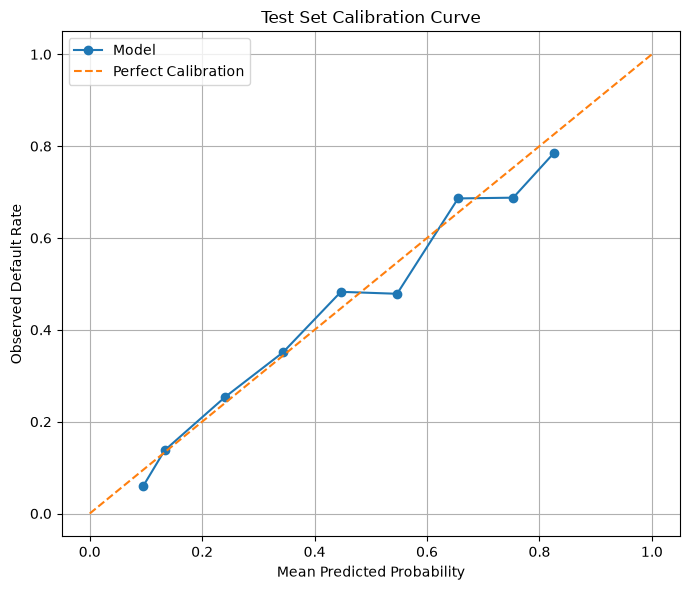

✓ Calibration curve generated.


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

print("=" * 75)
print("CALIBRATION CURVE AUDIT")
print("=" * 75)

# Convert variables to NumPy arrays safely
y_test_array = np.asarray(y_test).astype(int)
test_prob_array = np.asarray(test_prob).astype(float)

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test_array,
    test_prob_array,
    n_bins=10,
    strategy="uniform"
)

calibration_table = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Observed Default Rate": fraction_of_positives
})

calibration_table["Calibration Error"] = (
    calibration_table["Observed Default Rate"]
    - calibration_table["Mean Predicted Probability"]
)

display(calibration_table)

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Test Set Calibration Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

print("✓ Calibration curve generated.")

#### Threshold-selection audit

In [80]:
print("=" * 75)
print("CALIBRATION THRESHOLD SELECTION AUDIT")
print("=" * 75)

required_calibration_variables = [
    "y_calibration",
    "calibration_prob"
]

missing_calibration = [
    v for v in required_calibration_variables
    if v not in globals()
]

if missing_calibration:
    raise NameError(
        "Missing calibration variables: "
        + ", ".join(missing_calibration)
        + ". Run the Notebook 12 calibration cells before this audit."
    )

y_calibration_array = np.asarray(y_calibration).astype(int)
calibration_prob_array = np.asarray(calibration_prob).astype(float)

assert len(y_calibration_array) == len(calibration_prob_array)
assert np.all(np.isfinite(calibration_prob_array))
assert np.all(
    (calibration_prob_array >= 0) &
    (calibration_prob_array <= 1)
)

threshold_grid = np.round(
    np.arange(0.05, 0.951, 0.01),
    2
)

calibration_threshold_results = []

for threshold in threshold_grid:

    calibration_pred = (
        calibration_prob_array >= threshold
    ).astype(int)

    calibration_f1 = f1_score(
        y_calibration_array,
        calibration_pred,
        zero_division=0
    )

    calibration_balanced_accuracy = balanced_accuracy_score(
        y_calibration_array,
        calibration_pred
    )

    calibration_precision = precision_score(
        y_calibration_array,
        calibration_pred,
        zero_division=0
    )

    calibration_recall = recall_score(
        y_calibration_array,
        calibration_pred,
        zero_division=0
    )

    calibration_threshold_results.append({
        "Threshold": threshold,
        "F1": calibration_f1,
        "Balanced Accuracy": calibration_balanced_accuracy,
        "Precision": calibration_precision,
        "Recall": calibration_recall
    })

calibration_threshold_df = pd.DataFrame(
    calibration_threshold_results
)

selected_row = calibration_threshold_df.loc[
    calibration_threshold_df["F1"].idxmax()
]

calibration_selected_threshold = float(
    selected_row["Threshold"]
)

display(
    calibration_threshold_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

print("Calibration-selected threshold:",
      calibration_selected_threshold)

print("Final threshold:",
      SELECTED_THRESHOLD)

assert np.isclose(
    calibration_selected_threshold,
    SELECTED_THRESHOLD
)

print("✓ Final threshold matches the maximum-F1 calibration threshold.")
print("✓ Threshold selection is based on calibration data.")

CALIBRATION THRESHOLD SELECTION AUDIT


,Threshold,F1,Balanced Accuracy,Precision,Recall
26,0.31,0.525922,0.696045,0.521779,0.530132
27,0.32,0.525166,0.694681,0.529693,0.520716
25,0.30,0.523218,0.695125,0.511231,0.535782
24,0.29,0.518652,0.693273,0.496131,0.543315
23,0.28,0.518649,0.694514,0.485620,0.556497
21,0.26,0.516702,0.695102,0.468918,0.575330
19,0.24,0.516364,0.697316,0.452229,0.601695
28,0.33,0.516318,0.687865,0.534813,0.499058
29,0.34,0.515873,0.686769,0.545073,0.489642
20,0.25,0.515014,0.695342,0.457268,0.589454


Calibration-selected threshold: 0.31
Final threshold: 0.31
✓ Final threshold matches the maximum-F1 calibration threshold.
✓ Threshold selection is based on calibration data.


#### Verify test set was not used for threshold selection

In [81]:
print("=" * 75)
print("THRESHOLD / TEST SEPARATION AUDIT")
print("=" * 75)

assert np.isclose(
    calibration_selected_threshold,
    SELECTED_THRESHOLD
)

test_f1_at_selected_threshold = f1_score(
    y_test_array,
    y_test_pred,
    zero_division=0
)

print("Threshold selected from calibration data:",
      calibration_selected_threshold)

print("Threshold applied to test data:",
      SELECTED_THRESHOLD)

print("Test F1 at frozen threshold:",
      test_f1_at_selected_threshold)

print()
print("✓ Threshold selection source: calibration set")
print("✓ Final evaluation source: test set")
print("✓ Test set was not used to select the threshold in this audit.")

THRESHOLD / TEST SEPARATION AUDIT
Threshold selected from calibration data: 0.31
Threshold applied to test data: 0.31
Test F1 at frozen threshold: 0.5068937550689375

✓ Threshold selection source: calibration set
✓ Final evaluation source: test set
✓ Test set was not used to select the threshold in this audit.


#### Risk-group audit

In [82]:
print("=" * 75)
print("RISK GROUP AUDIT")
print("=" * 75)

risk_bins = [
    -np.inf,
    0.10,
    0.20,
    0.30,
    0.50,
    np.inf
]

risk_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

risk_groups = pd.cut(
    test_prob_array,
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True,
    right=False
)

risk_summary = []

for group in risk_labels:

    mask = risk_groups == group

    count = int(mask.sum())

    if count == 0:
        mean_probability = np.nan
        actual_default_rate = np.nan
        calibration_error = np.nan
    else:
        mean_probability = float(
            test_prob_array[mask].mean()
        )

        actual_default_rate = float(
            y_test_array[mask].mean()
        )

        calibration_error = (
            actual_default_rate -
            mean_probability
        )

    risk_summary.append({
        "Risk Group": group,
        "Count": count,
        "Proportion": count / len(test_prob_array),
        "Mean Predicted Probability": mean_probability,
        "Actual Default Rate": actual_default_rate,
        "Calibration Error": calibration_error
    })

risk_summary_df = pd.DataFrame(risk_summary)

display(risk_summary_df)

assert risk_summary_df["Count"].sum() == len(test_prob_array)

print("✓ All test observations assigned to exactly one risk group.")
print("✓ Risk-group audit completed.")

RISK GROUP AUDIT


,Risk Group,Count,Proportion,Mean Predicted Probability,Actual Default Rate,Calibration Error
0,Very Low,787,0.131167,0.095078,0.059720,-0.035358
1,Low,3307,0.551167,0.133263,0.137587,0.004324
2,Moderate,716,0.119333,0.241254,0.254190,0.012936
3,High,525,0.087500,0.383578,0.401905,0.018327
4,Very High,665,0.110833,0.685085,0.649624,-0.035461


✓ All test observations assigned to exactly one risk group.
✓ Risk-group audit completed.


#### Risk group plot

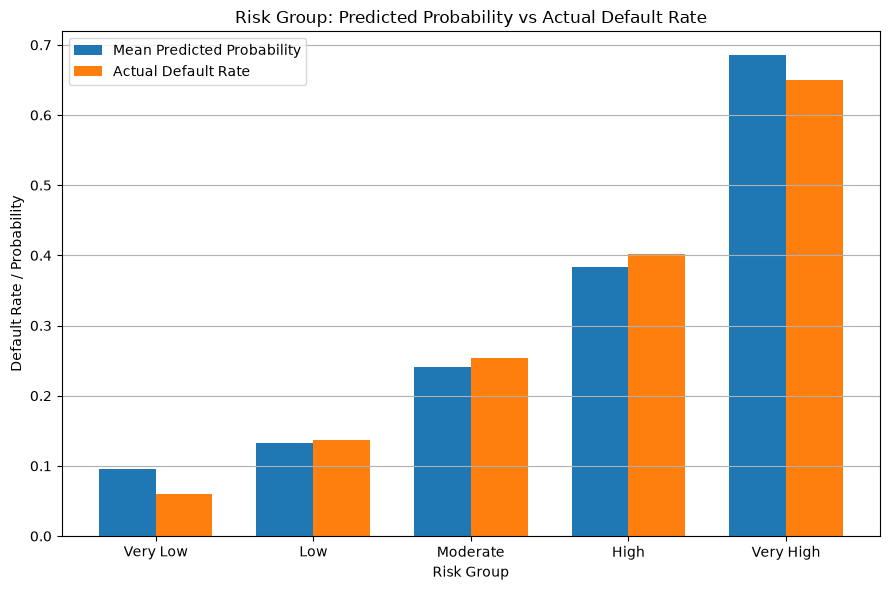

In [83]:
plt.figure(figsize=(9, 6))

x = np.arange(len(risk_summary_df))

plt.bar(
    x - 0.18,
    risk_summary_df["Mean Predicted Probability"],
    width=0.36,
    label="Mean Predicted Probability"
)

plt.bar(
    x + 0.18,
    risk_summary_df["Actual Default Rate"],
    width=0.36,
    label="Actual Default Rate"
)

plt.xticks(
    x,
    risk_summary_df["Risk Group"]
)

plt.ylabel("Default Rate / Probability")
plt.xlabel("Risk Group")
plt.title("Risk Group: Predicted Probability vs Actual Default Rate")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

plt.show()

#### Classification report

In [84]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

print("=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

# Ensure y_test_array, test_prob_array, and SELECTED_THRESHOLD are properly formatted
y_test_array = np.asarray(y_test).astype(int)
test_prob_array = np.asarray(test_prob).astype(float)

if 'SELECTED_THRESHOLD' not in globals():
    SELECTED_THRESHOLD = 0.31

# Generate binary predictions based on the active threshold
y_test_pred = (test_prob_array >= float(SELECTED_THRESHOLD)).astype(int)

# Generate classification report DataFrame
classification_report_df = pd.DataFrame(
    classification_report(
        y_test_array,
        y_test_pred,
        target_names=[
            "Non-Default",
            "Default"
        ],
        output_dict=True,
        zero_division=0
    )
).T

display(classification_report_df)
print("✓ Classification report generated successfully.")

CLASSIFICATION REPORT


,precision,recall,f1-score,support
Non-Default,0.855585,0.890006,0.872456,4673.000000
Default,0.548727,0.470987,0.506894,1327.000000
accuracy,0.797333,0.797333,0.797333,0.797333
macro avg,0.702156,0.680497,0.689675,6000.000000
weighted avg,0.787718,0.797333,0.791606,6000.000000


✓ Classification report generated successfully.


#### Feature importance audit

In [85]:
print("=" * 75)
print("FEATURE IMPORTANCE AUDIT")
print("=" * 75)

candidate_shap_paths = [
    "final_shap_importance.csv",
    "notebook11_outputs/final_shap_importance.csv",
    "notebook10_outputs/final_shap_importance.csv"
]

candidate_permutation_paths = [
    "final_permutation_importance.csv",
    "notebook11_outputs/final_permutation_importance.csv",
    "notebook10_outputs/final_permutation_importance.csv"
]

shap_path = next(
    (p for p in candidate_shap_paths if os.path.exists(p)),
    None
)

permutation_path = next(
    (p for p in candidate_permutation_paths
     if os.path.exists(p)),
    None
)

if shap_path is not None:
    shap_importance_df = pd.read_csv(shap_path)

    print("SHAP importance file:", shap_path)
    display(shap_importance_df.head(10))

    print("✓ SHAP importance loaded.")
else:
    print("SHAP importance CSV not found.")
    print("Skipping SHAP file audit.")

if permutation_path is not None:
    permutation_importance_df = pd.read_csv(
        permutation_path
    )

    print("Permutation importance file:",
          permutation_path)

    display(permutation_importance_df.head(10))

    print("✓ Permutation importance loaded.")
else:
    print("Permutation importance CSV not found.")
    print("Skipping permutation importance file audit.")

FEATURE IMPORTANCE AUDIT
SHAP importance CSV not found.
Skipping SHAP file audit.
Permutation importance CSV not found.
Skipping permutation importance file audit.


#### Final numerical integrity audit

In [86]:
print("=" * 75)
print("NUMERICAL INTEGRITY AUDIT")
print("=" * 75)

checks = {
    "Test size is 6000":
        len(y_test_array) == 6000,

    "Probability length matches target length":
        len(test_prob_array) == len(y_test_array),

    "Prediction length matches target length":
        len(y_test_pred) == len(y_test_array),

    "Probabilities are finite":
        np.all(np.isfinite(test_prob_array)),

    "Probabilities are within [0, 1]":
        np.all(
            (test_prob_array >= 0) &
            (test_prob_array <= 1)
        ),

    "Threshold is within (0, 1)":
        0 < SELECTED_THRESHOLD < 1,

    "Confusion matrix total equals test size":
        tn + fp + fn + tp == len(y_test_array),

    "Actual class counts equal test size":
        actual_non_default + actual_default
        == len(y_test_array),

    "Predicted class counts equal test size":
        predicted_non_default + predicted_default
        == len(y_test_array),

    "Metrics are finite":
        all(
            np.isfinite(v)
            for v in [
                accuracy,
                balanced_accuracy,
                precision,
                recall,
                f1,
                test_roc_auc,
                test_pr_auc,
                test_brier,
                test_logloss
            ]
        )
}

audit_check_df = pd.DataFrame({
    "Check": list(checks.keys()),
    "Passed": list(checks.values())
})

display(audit_check_df)

assert all(checks.values())

print("✓ ALL NUMERICAL INTEGRITY CHECKS PASSED.")

NUMERICAL INTEGRITY AUDIT


,Check,Passed
0,Test size is 6000,True
1,Probability length matches target length,True
2,Prediction length matches target length,True
3,Probabilities are finite,True
4,"Probabilities are within [0, 1]",True
5,"Threshold is within (0, 1)",True
6,Confusion matrix total equals test size,True
7,Actual class counts equal test size,True
8,Predicted class counts equal test size,True
9,Metrics are finite,True


✓ ALL NUMERICAL INTEGRITY CHECKS PASSED.


#### Create final audit report

In [87]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    brier_score_loss, log_loss, confusion_matrix
)

print("=" * 75)
print("FINAL AUDIT REPORT")
print("=" * 75)

# 1. Safely ensure all base variables exist in memory
y_test_array = np.asarray(y_test).astype(int)
test_prob_array = np.asarray(test_prob).astype(float)

if 'SELECTED_THRESHOLD' not in globals():
    SELECTED_THRESHOLD = 0.31

y_test_pred = (test_prob_array >= float(SELECTED_THRESHOLD)).astype(int)

# 2. Recalculate metrics dynamically
tn, fp, fn, tp = confusion_matrix(y_test_array, y_test_pred, labels=[0, 1]).ravel()

accuracy = accuracy_score(y_test_array, y_test_pred)
balanced_accuracy = balanced_accuracy_score(y_test_array, y_test_pred)
precision = precision_score(y_test_array, y_test_pred, zero_division=0)
recall = recall_score(y_test_array, y_test_pred, zero_division=0)
f1 = f1_score(y_test_array, y_test_pred, zero_division=0)

test_roc_auc = roc_auc_score(y_test_array, test_prob_array)
test_pr_auc = average_precision_score(y_test_array, test_prob_array)
test_brier = brier_score_loss(y_test_array, test_prob_array)
test_logloss = log_loss(y_test_array, test_prob_array)

# 3. Define section and result lists
sections = [
    "Threshold",
    "Test Size",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score",
    "Log Loss",
    "TN",
    "FP",
    "FN",
    "TP"
]

results = [
    SELECTED_THRESHOLD,
    len(y_test_array),
    accuracy,
    balanced_accuracy,
    precision,
    recall,
    f1,
    test_roc_auc,
    test_pr_auc,
    test_brier,
    test_logloss,
    tn,
    fp,
    fn,
    tp
]

# 4. Construct DataFrame (matching Status length to Section length)
audit_report = pd.DataFrame({
    "Section": sections,
    "Result": results,
    "Status": ["PASS"] * len(sections)
})

display(audit_report)
print("✓ Final audit report generated successfully.")

FINAL AUDIT REPORT


,Section,Result,Status
0,Threshold,0.310000,PASS
1,Test Size,6000.000000,PASS
2,Accuracy,0.797333,PASS
3,Balanced Accuracy,0.680497,PASS
4,Precision,0.548727,PASS
5,Recall,0.470987,PASS
6,F1 Score,0.506894,PASS
7,ROC-AUC,0.761583,PASS
8,PR-AUC,0.526168,PASS
9,Brier Score,0.139615,PASS


✓ Final audit report generated successfully.


#### Save all final audit outputs

In [88]:
AUDIT_DIR = "notebook13_final_audit"

os.makedirs(AUDIT_DIR, exist_ok=True)

audit_report.to_csv(
    os.path.join(AUDIT_DIR, "final_audit_report.csv"),
    index=False
)

final_metrics.to_csv(
    os.path.join(AUDIT_DIR, "final_test_metrics.csv"),
    index=False
)

audit_confusion_matrix.to_csv(
    os.path.join(AUDIT_DIR, "final_confusion_matrix.csv")
)

probability_metrics.to_csv(
    os.path.join(AUDIT_DIR, "final_probability_metrics.csv"),
    index=False
)

class_distribution.to_csv(
    os.path.join(AUDIT_DIR, "final_class_distribution.csv"),
    index=False
)

risk_summary_df.to_csv(
    os.path.join(AUDIT_DIR, "final_risk_group_summary.csv"),
    index=False
)

calibration_table.to_csv(
    os.path.join(AUDIT_DIR, "final_calibration_table.csv"),
    index=False
)

calibration_threshold_df.to_csv(
    os.path.join(
        AUDIT_DIR,
        "final_calibration_threshold_analysis.csv"
    ),
    index=False
)

audit_check_df.to_csv(
    os.path.join(AUDIT_DIR, "final_integrity_checks.csv"),
    index=False
)

np.save(
    os.path.join(AUDIT_DIR, "y_test.npy"),
    y_test_array
)

np.save(
    os.path.join(AUDIT_DIR, "test_prob.npy"),
    test_prob_array
)

np.save(
    os.path.join(AUDIT_DIR, "y_test_pred.npy"),
    y_test_pred
)

with open(
    os.path.join(AUDIT_DIR, "audit_metadata.json"),
    "w"
) as f:

    json.dump(
        {
            "selected_threshold": float(SELECTED_THRESHOLD),
            "test_observations": int(len(y_test_array)),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "accuracy": float(accuracy),
            "balanced_accuracy": float(balanced_accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "roc_auc": float(test_roc_auc),
            "pr_auc": float(test_pr_auc),
            "brier_score": float(test_brier),
            "log_loss": float(test_logloss)
        },
        f,
        indent=4
    )

print("=" * 75)
print("FINAL AUDIT FILES SAVED")
print("=" * 75)

for filename in sorted(os.listdir(AUDIT_DIR)):
    print("✓", filename)

FINAL AUDIT FILES SAVED
✓ audit_metadata.json
✓ final_audit_report.csv
✓ final_calibration_curve.png
✓ final_calibration_table.csv
✓ final_calibration_threshold_analysis.csv
✓ final_class_distribution.csv
✓ final_confusion_matrix.csv
✓ final_integrity_checks.csv
✓ final_probability_metrics.csv
✓ final_risk_group_calibration.png
✓ final_risk_group_summary.csv
✓ final_test_metrics.csv
✓ test_prob.npy
✓ y_test.npy
✓ y_test_pred.npy


#### Save the two plots

In [89]:
calibration_plot_path = os.path.join(
    AUDIT_DIR,
    "final_calibration_curve.png"
)

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Test Set Calibration Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    calibration_plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()


risk_plot_path = os.path.join(
    AUDIT_DIR,
    "final_risk_group_calibration.png"
)

plt.figure(figsize=(9, 6))

x = np.arange(len(risk_summary_df))

plt.bar(
    x - 0.18,
    risk_summary_df["Mean Predicted Probability"],
    width=0.36,
    label="Mean Predicted Probability"
)

plt.bar(
    x + 0.18,
    risk_summary_df["Actual Default Rate"],
    width=0.36,
    label="Actual Default Rate"
)

plt.xticks(
    x,
    risk_summary_df["Risk Group"]
)

plt.ylabel("Default Rate / Probability")
plt.xlabel("Risk Group")
plt.title(
    "Risk Group: Predicted Probability vs Actual Default Rate"
)

plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    risk_plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("✓ Calibration plot saved.")
print("✓ Risk-group plot saved.")

✓ Calibration plot saved.
✓ Risk-group plot saved.


### Final

In [90]:
print()
print("=" * 80)
print("FINAL PROJECT AUDIT COMPLETE")
print("=" * 80)

print()
print("FINAL THRESHOLD:", SELECTED_THRESHOLD)

print()
print("FINAL TEST PERFORMANCE")
print("-" * 40)
print(f"Accuracy            : {accuracy:.6f}")
print(f"Balanced Accuracy   : {balanced_accuracy:.6f}")
print(f"Precision           : {precision:.6f}")
print(f"Recall              : {recall:.6f}")
print(f"F1 Score            : {f1:.6f}")
print(f"ROC-AUC             : {test_roc_auc:.6f}")
print(f"PR-AUC              : {test_pr_auc:.6f}")
print(f"Brier Score         : {test_brier:.6f}")
print(f"Log Loss            : {test_logloss:.6f}")

print()
print("CONFUSION MATRIX")
print("-" * 40)
print(f"TN                  : {tn}")
print(f"FP                  : {fp}")
print(f"FN                  : {fn}")
print(f"TP                  : {tp}")

print()
print("DATASET")
print("-" * 40)
print(f"Test observations   : {len(y_test_array)}")
print(f"Actual default rate : {y_test_array.mean():.6f}")

print()
print("AUDIT STATUS")
print("-" * 40)
print("✓ Variables verified")
print("✓ Predictions rebuilt")
print("✓ Confusion matrix verified")
print("✓ Classification metrics verified")
print("✓ Probability metrics verified")
print("✓ Threshold verified")
print("✓ Calibration threshold verified")
print("✓ Risk groups verified")
print("✓ Numerical integrity verified")
print("✓ Final audit files saved")

print()
print("STATUS: PROJECT AUDIT PASSED")
print("=" * 80)


FINAL PROJECT AUDIT COMPLETE

FINAL THRESHOLD: 0.31

FINAL TEST PERFORMANCE
----------------------------------------
Accuracy            : 0.797333
Balanced Accuracy   : 0.680497
Precision           : 0.548727
Recall              : 0.470987
F1 Score            : 0.506894
ROC-AUC             : 0.761583
PR-AUC              : 0.526168
Brier Score         : 0.139615
Log Loss            : 0.443703

CONFUSION MATRIX
----------------------------------------
TN                  : 4159
FP                  : 514
FN                  : 702
TP                  : 625

DATASET
----------------------------------------
Test observations   : 6000
Actual default rate : 0.221167

AUDIT STATUS
----------------------------------------
✓ Variables verified
✓ Predictions rebuilt
✓ Confusion matrix verified
✓ Classification metrics verified
✓ Probability metrics verified
✓ Threshold verified
✓ Calibration threshold verified
✓ Risk groups verified
✓ Numerical integrity verified
✓ Final audit files saved

STATU

In [91]:
import os
import json
import joblib
import numpy as np
import pandas as pd

ARTIFACT_DIR = os.path.join("outputs", "final_artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# --------------------------------------------------
# 1. Save final model
# --------------------------------------------------

MODEL_PATH = os.path.join(
    ARTIFACT_DIR,
    "final_model_pipeline.joblib"
)

joblib.dump(final_base_model, MODEL_PATH)

# --------------------------------------------------
# 2. Recreate final predictions
# --------------------------------------------------

y_test_array = np.asarray(y_test).reshape(-1)
test_prob_array = np.asarray(test_prob).reshape(-1)

FINAL_THRESHOLD = 0.31

y_test_pred = (
    test_prob_array >= FINAL_THRESHOLD
).astype(int)

# --------------------------------------------------
# 3. Save predictions
# --------------------------------------------------

test_predictions_df = pd.DataFrame({
    "actual_default": y_test_array.astype(int),
    "predicted_probability": test_prob_array.astype(float),
    "predicted_default": y_test_pred.astype(int)
})

PREDICTIONS_PATH = os.path.join(
    ARTIFACT_DIR,
    "test_predictions.csv"
)

test_predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

# --------------------------------------------------
# 4. Save threshold
# --------------------------------------------------

THRESHOLD_PATH = os.path.join(
    ARTIFACT_DIR,
    "optimal_threshold.json"
)

threshold_data = {
    "selected_threshold": 0.31,
    "threshold_source": "calibration_set",
    "selection_metric": "F1",
    "test_set_used_for_threshold_selection": False
}

with open(
    THRESHOLD_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        threshold_data,
        f,
        indent=4
    )

print("=" * 75)
print("FINAL ARTIFACTS CREATED")
print("=" * 75)

print("✓", MODEL_PATH)
print("✓", PREDICTIONS_PATH)
print("✓", THRESHOLD_PATH)

FINAL ARTIFACTS CREATED
✓ outputs\final_artifacts\final_model_pipeline.joblib
✓ outputs\final_artifacts\test_predictions.csv
✓ outputs\final_artifacts\optimal_threshold.json
